## Language Endangerment: An Analysis of Glottolog Data

This report delves into the fascinating world of human languages using data from Glottolog, a comprehensive online catalog of the world's languages. Glottolog provides detailed information on languages, their genetic relationships, geographical locations, and, crucially for this analysis, their endangerment status. The dataset allows us to explore global linguistic diversity and identify patterns related to how languages are organized into families, where they are spoken, and their current vitality.

Our primary objective is to investigate factors influencing language endangerment. Specifically, we will examine the relationship between a language's family structure (whether it belongs to a large family or is an 'isolate') and its risk of becoming endangered or extinct. By analyzing the distribution of language family sizes and comparing the endangerment profiles of isolated versus non-isolated languages, along with their geographical distribution, we aim to uncover insights that contribute to a better understanding of language vitality and the challenges faced by many languages today.

In [ ]:
import pandas as pd

# Load and clean endangered_status
# Reading from the raw URL
raw_values_url = "https://raw.githubusercontent.com/glottolog/glottolog-cldf/refs/heads/master/cldf/values.csv"
endangered_status = pd.read_csv(raw_values_url)

# Filtering for Parameter_ID == "aes" (Agglomerated Endangerment Status)
endangered_status = endangered_status[endangered_status['Parameter_ID'] == 'aes']

# Selecting and Renaming
endangered_status = endangered_status[['Language_ID', 'Value', 'Code_ID']].rename(
    columns={'Language_ID': 'id', 'Value': 'status_code', 'Code_ID': 'status_label'}
)

# String cleaning (Removing "aes-" prefix and replacing "_" with space)
endangered_status['status_label'] = (
    endangered_status['status_label']
    .str.replace(r'^aes-', '', regex=True)
    .str.replace('_', ' ')
)

In [ ]:
print(endangered_status.head())

          id status_code    status_label
33  fasu1242           3        shifting
40  wash1253           4        moribund
47  taua1242           1  not endangered
57  puel1244           6         extinct
64  tuxa1239           6         extinct


In [ ]:
print(endangered_status.shape)

(8672, 3)


In [ ]:
# Status labels
endangered_status['status_label'].unique()

array(['shifting', 'moribund', 'not endangered', 'extinct',
       'nearly extinct', 'threatened'], dtype=object)

In [ ]:
# Load Language and Family data
raw_lgs_url = "https://raw.githubusercontent.com/glottolog/glottolog-cldf/refs/heads/master/cldf/languages.csv"
fam_lgs = pd.read_csv(raw_lgs_url)

# Filter and clean Families
families = fam_lgs[fam_lgs['Level'] == 'family'].copy()
families = families[['ID', 'Name']].rename(columns={'ID': 'id', 'Name': 'family'})
# Ensure all column names are lowercase (dplyr's rename_with equivalent)
families.columns = families.columns.str.lower()

In [ ]:
print(families.head())

         id        family
0  abkh1242  Abkhaz-Adyge
1  surm1244        Surmic
2  tama1329        Tamaic
3  yare1250       Yareban
4  monu1249         Bogia


In [ ]:
print(families.shape) # 4853

(4853, 2)


In [ ]:
# Filter and clean Languages
languages = fam_lgs[fam_lgs['Level'] == 'language'].copy()
cols_to_keep = ['ID', 'Name', 'Macroarea', 'Latitude', 'Longitude',
                'ISO639P3code', 'Countries', 'Is_Isolate', 'Family_ID']
languages = languages[cols_to_keep]

# Lowercase all column names
languages.columns = languages.columns.str.lower()

In [ ]:
print(languages.head())

          id     name      macroarea   latitude   longitude iso639p3code  \
10  fasu1242     Fasu      Papunesia  -6.626870  143.284000          faa   
11  wash1253    Washo  North America  38.818400 -119.640000          was   
12  taua1242   Tauade      Papunesia  -8.348600  147.094000          ttd   
14  puel1244  Puelche  South America -42.223000  -68.666000          pue   
15  tuxa1239     Tuxá  South America  -8.953642  -38.274229          tud   

   countries is_isolate family_id  
10        PG       True       NaN  
11        US       True       NaN  
12        PG       True       NaN  
14        AR       True       NaN  
15        BR       True       NaN  


In [ ]:
#df_families = languages[languages['family_id'].notna()].copy() # filter for rows where languages is NOT NaN

df_families = languages.copy()
df_families['is_isolate'] = df_families['family_id'].isna()
# Merging cleaned Languages and Endangered_Status data
table1 = df_families.merge(endangered_status, on = 'id', how = 'left')
table1 = df_families.merge(endangered_status, on = 'id', how = 'left')

In [ ]:
# Merging new data with Families data
table2 = table1.merge(families, left_on = 'family_id', right_on = 'id', how = 'left')

In [ ]:
yappers = table2.drop(columns='id_y').rename(columns={'id_x': 'id'})
print(yappers.head())
print(f"Please use feel free to use yappers as your cleaned data. it contains all the relevant columns we need :) Thanks!")

         id     name      macroarea   latitude   longitude iso639p3code  \
0  fasu1242     Fasu      Papunesia  -6.626870  143.284000          faa   
1  wash1253    Washo  North America  38.818400 -119.640000          was   
2  taua1242   Tauade      Papunesia  -8.348600  147.094000          ttd   
3  puel1244  Puelche  South America -42.223000  -68.666000          pue   
4  tuxa1239     Tuxá  South America  -8.953642  -38.274229          tud   

  countries  is_isolate family_id status_code    status_label family  
0        PG        True       NaN           3        shifting    NaN  
1        US        True       NaN           4        moribund    NaN  
2        PG        True       NaN           1  not endangered    NaN  
3        AR        True       NaN           6         extinct    NaN  
4        BR        True       NaN           6         extinct    NaN  
Please use feel free to use yappers as your cleaned data. it contains all the relevant columns we need :) Thanks!


## 2. Data Cleaning and Summary

The initial dataset was constructed by merging information from several Glottolog CSV files. We began by loading `values.csv` to extract language endangerment statuses, specifically focusing on the 'Agglomerated Endangerment Status' (`Parameter_ID == 'aes'`). This involved filtering, renaming columns to `id`, `status_code`, and `status_label`, and cleaning `status_label` by removing prefixes and replacing underscores. Concurrently, `languages.csv` was loaded to obtain language-specific details such as names, macroarea, geographical coordinates, ISO codes, and family IDs. This file was further processed to differentiate between language entries and family entries, creating separate `languages` and `families` dataframes.

The `languages` dataframe was cleaned by selecting relevant columns and converting them to lowercase. A crucial step involved creating an `is_isolate` column, indicating whether a language has a `family_id` (False) or not (True). Finally, these cleaned dataframes were merged: `languages` with `endangered_status` (on `id`) to form `table1`, and then `table1` with `families` (on `family_id`) to incorporate family names. The resulting `yappers` dataframe, which is the cleaned and prepared dataset for our analysis, consolidates all relevant information, allowing us to proceed with exploratory data analysis and visualization. The final dataframe contains language-level data enriched with endangerment status and family information.

In [ ]:
print("Shape of the final dataframe (yappers):")
print(yappers.shape)
print("\nInformation about yappers dataframe:")
yappers.info()
print("\nDescriptive statistics for numerical columns:")
display(yappers.describe())
print("\nValue counts for 'status_label':")
display(yappers['status_label'].value_counts(dropna=False))
print("\nValue counts for 'is_isolate':")
display(yappers['is_isolate'].value_counts(dropna=False))

## 3. Visualizations

In [ ]:
yappers['status_label'].unique()

array(['shifting', 'moribund', 'not endangered', 'extinct',
       'nearly extinct', 'threatened', nan], dtype=object)

PLOT 1 : How many languages are usually in a family

### Plot 1: Isolates vs. Language Family Sizes

This bar chart visualizes the distribution of language family sizes and the number of isolated languages. It addresses the question: "How many languages are usually in a family?"

*   **Variables Used**: The plot implicitly uses the `family` column to group languages and count the `id` of each language within these families. The `is_isolate` column is used to distinguish languages without a family. The family sizes are then categorized into `size_bucket`s (e.g., '2–5', '6–10', '11–50', '51–100', '100+').
*   **Why this visualization?**: A bar chart is highly effective for comparing discrete categories and their corresponding counts. It clearly shows the numerical dominance of isolated languages compared to languages grouped into families, and it illustrates the distribution of family sizes across different buckets, providing a quick overview of language family structures.

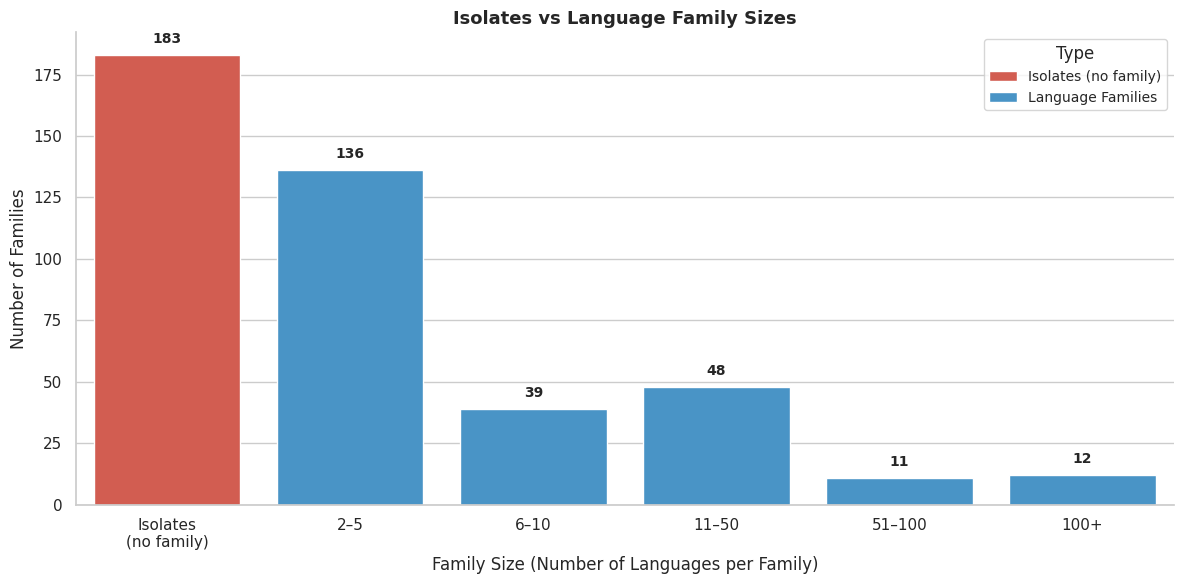

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# FIX 1: Change 'Not Isolate' to False
langs_per_family = (
    yappers[yappers['is_isolate'] == False]
    .groupby('family')['id']
    .count()
    .reset_index()
    .rename(columns={'id': 'num_languages'})
)

bins = [0, 5, 10, 50, 100, np.inf]
labels = ['2–5', '6–10', '11–50', '51–100', '100+']

langs_per_family['size_bucket'] = pd.cut(
    langs_per_family['num_languages'],
    bins=bins,
    labels=labels
)

bucket_counts = (
    langs_per_family['size_bucket']
    .value_counts()
    .reindex(labels)
    .reset_index()
)

bucket_counts.columns = ['size_bucket', 'count']

# FIX 2: Change 'Isolate' to True
isolate_count = yappers[yappers['is_isolate'] == True]['id'].nunique()

isolate_row = pd.DataFrame({
    'size_bucket': ['Isolates\n(no family)'],
    'count': [isolate_count]
})

bucket_counts = pd.concat([isolate_row, bucket_counts], ignore_index=True)

bucket_counts['type'] = (
    ['Isolates (no family)'] + ['Language Families'] * len(labels)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=bucket_counts,
    x='size_bucket',
    y='count',
    hue='type',
    palette={
        'Isolates (no family)': '#e74c3c',
        'Language Families': '#3498db'
    },
    dodge=False,
    legend=True
)

# Adding the value labels on top of the bars
for i, val in enumerate(bucket_counts['count']):
    plt.text(
        i,
        val + (bucket_counts['count'].max() * 0.02),
        str(int(val)),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.xlabel('Family Size (Number of Languages per Family)', fontsize=12)
plt.ylabel('Number of Families', fontsize=12)
plt.title('Isolates vs Language Family Sizes', fontsize=13, fontweight='bold')

plt.legend(title='Type', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

KIV : Better graph

plot is misleading
1) Seems like isolates have the most family
2) It is misleading.

Plot 2 : Is Isolation a Risk Factor?

### Plot 2: Is Isolation a Risk Factor?

This stacked bar chart compares the endangerment status distribution between isolated languages and non-isolated languages. It directly explores whether being an 'isolate' increases a language's risk of endangerment.

*   **Variables Used**: The primary categorical variable is `is_isolate` (transformed to 'Isolate' or 'Not Isolate'), which forms the main bars. The `status_label` (endangerment levels like 'not endangered', 'threatened', 'extinct') constitutes the stacked segments within each bar.
*   **Why this visualization?**: A stacked bar chart is ideal for showing the composition of different categories (endangerment statuses) within two main groups (isolated vs. non-isolated) and for comparing their proportional distributions. By normalizing the bars to 100%, it allows for a clear visual comparison of the *percentage* of languages in each endangerment category for both isolated and non-isolated groups, making it easy to identify shifts in endangerment profiles.

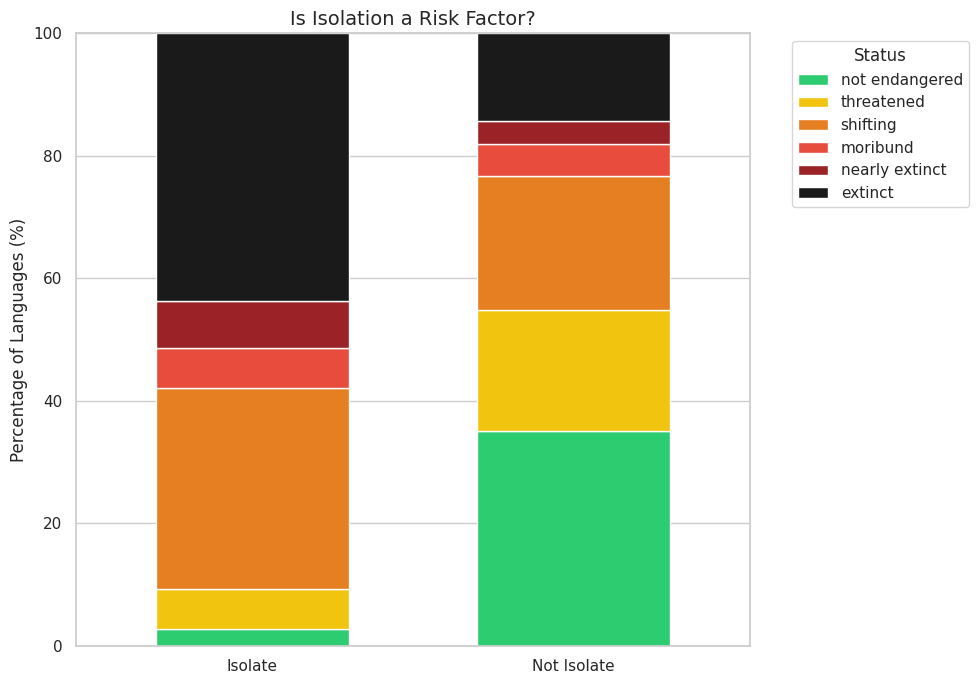

In [ ]:
#plot 2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

danger_palette = {
    'not endangered': '#2ecc71',
    'threatened': '#f1c40f',
    'shifting': '#e67e22',
    'moribund': '#e74c3c',
    'nearly extinct': '#9b2226',
    'extinct': '#1a1a1a'
}
status_order = ["not endangered", "threatened", "shifting", "moribund", "nearly extinct", "extinct"]

yappers['is_isolate'] = yappers['is_isolate'].map({True: 'Isolate', False: 'Not Isolate', 1: 'Isolate', 0: 'Not Isolate'})
yappers['is_isolate'] = yappers['is_isolate'].fillna('Not Isolate')

pivot = yappers.groupby(['is_isolate', 'status_label']).size().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

ax = pivot_pct[status_order].plot(
    kind='bar',
    stacked=True,
    color=[danger_palette[s] for s in status_order],
    figsize=(10, 7),
    width=0.6
)

plt.title("Is Isolation a Risk Factor?", fontsize=14)
plt.ylabel("Percentage of Languages (%)")
plt.xlabel("")
plt.legend(title="Status", bbox_to_anchor=(1.05, 1))
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Insight
* It is evident that there are significantly higher percentage of extinct status in Isolates over Non-Isolates.


### Plot 3: Geographical Distribution of Isolated Languages by Endangerment Status

These scatter plots visualize the geographical distribution of *isolated* languages, categorized by their endangerment status (critical vs. non-critical). This allows us to observe any spatial patterns in the endangerment of isolated languages.

*   **Variables Used**: `longitude` and `latitude` define the geographical position of each language. `status_label` (endangerment level) is used for coloring the points, with languages explicitly filtered for `is_isolate == 'Isolate'`. The plot is split into two subplots based on whether the status is 'critical' (moribund, nearly extinct, extinct) or 'non-critical' (not endangered, threatened, shifting).
*   **Why this visualization?**: Scatter plots are suitable for displaying individual data points based on two continuous numerical variables (longitude and latitude), effectively mapping languages onto a global scale. Using different colors for `status_label` and separating critical from non-critical states allows for easy identification of clusters or regions where critically endangered isolated languages might be concentrated, offering a spatial dimension to our analysis of risk factors.

In [ ]:
yappers['is_isolate']

,is_isolate
0,Isolate
1,Isolate
2,Isolate
3,Isolate
4,Isolate
...,...
8613,Not Isolate
8614,Not Isolate
8615,Not Isolate
8616,Not Isolate


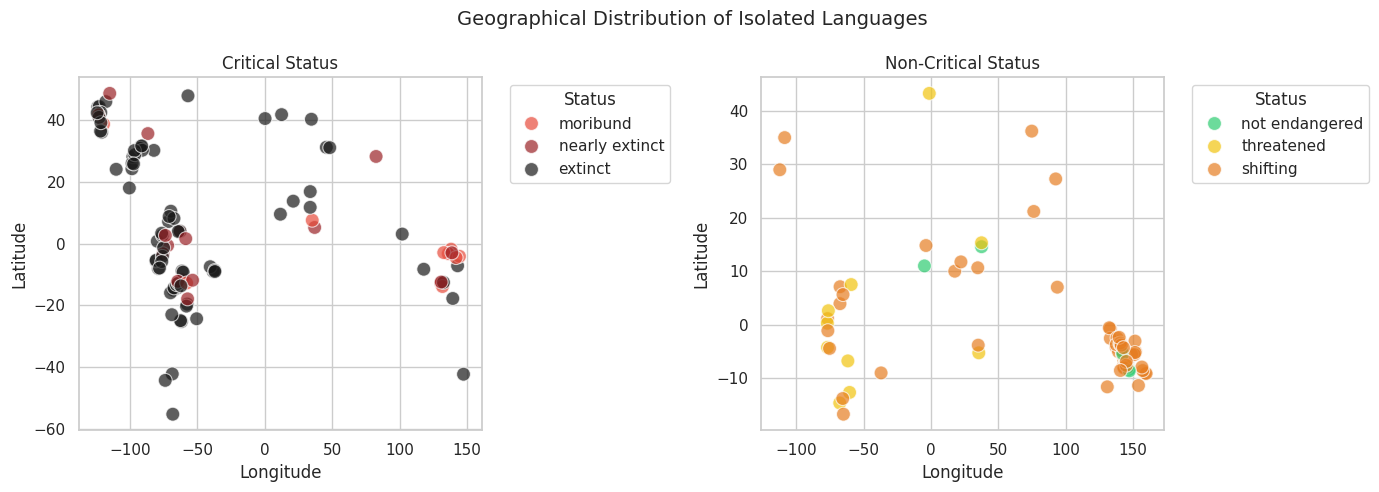

In [ ]:
sns.set_theme(style="whitegrid")

critical_status = ['moribund', 'nearly extinct', 'extinct']
non_critical_status = ["not endangered", "threatened", "shifting"]


extinct_true = yappers[(yappers['is_isolate']=='Isolate') &
                       (yappers['status_label'].isin(critical_status))]

extinct_false = yappers[(yappers['is_isolate']=='Isolate') &
                        (yappers['status_label'].isin(non_critical_status))]

fig, ax = plt.subplots(1, 2, figsize=(14,5))

danger_palette = {
    'not endangered': '#2ecc71',
    'threatened': '#f1c40f',
    'shifting': '#e67e22',
    'moribund': '#e74c3c',
    'nearly extinct': '#9b2226',
    'extinct': '#1a1a1a'
}

critical_order = ['moribund', 'nearly extinct', 'extinct']
non_critical_order = ['not endangered', 'threatened', 'shifting']

sns.scatterplot(
    data=extinct_true,
    x="longitude", y="latitude",
    hue="status_label", hue_order=critical_order,
    palette=danger_palette,
    alpha=0.7, s=100, edgecolor='w',
    ax=ax[0]
)
ax[0].set_title("Critical Status", fontsize=12)

sns.scatterplot(
    data=extinct_false,
    x="longitude", y="latitude",
    hue="status_label", hue_order=non_critical_order,
    palette=danger_palette,
    alpha=0.7, s=100, edgecolor='w',
    ax=ax[1]
)
ax[1].set_title("Non-Critical Status", fontsize=12)

# Labels
for a in ax:
    a.set_xlabel("Longitude")
    a.set_ylabel("Latitude")

ax[0].legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')
ax[1].legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')

fig.suptitle("Geographical Distribution of Isolated Languages", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Discussions

### Discussion of Plot 1: Isolates vs. Language Family Sizes

Plot 1, "Isolates vs. Language Family Sizes," reveals a significant aspect of global linguistic diversity: the sheer number of isolated languages. The chart clearly indicates that 'Isolates (no family)' represent a very large proportion of individual languages, often outnumbering languages within many family size buckets. Among language families, the smallest categories (2–5 and 6–10 languages) are the most numerous, suggesting that while many languages belong to families, a substantial number of these families are relatively small. Larger families (e.g., 51–100 or 100+ languages) are considerably less frequent. This distribution highlights that linguistic diversity isn't solely driven by large, sprawling language families, but also by a vast array of unique, independent languages and smaller family units. This insight is crucial for understanding the overall linguistic landscape and points to the potential vulnerability of these smaller groups.

### Discussion of Plot 2: Is Isolation a Risk Factor?

Plot 2, "Is Isolation a Risk Factor?", provides a stark comparison of endangerment statuses between isolated and non-isolated languages. As previously noted, it is evident that a significantly higher percentage of isolated languages are classified as 'extinct' compared to non-isolated languages. While both categories show languages across all endangerment statuses, the proportion of languages in 'moribund', 'nearly extinct', and especially 'extinct' categories is markedly higher for isolates. Conversely, non-isolated languages tend to have a larger proportion in the 'not endangered' and 'threatened' categories. This suggests that belonging to a larger language family might offer some protective factor, perhaps due to a larger speaker base, more shared resources, or greater institutional support. Isolated languages, lacking these familial ties, appear to be more susceptible to the pressures leading to extinction.

### Discussion of Plot 3: Geographical Distribution of Isolated Languages by Endangerment Status

Plot 3, "Geographical Distribution of Isolated Languages by Endangerment Status," offers a spatial perspective on the vulnerability of isolated languages. By distinguishing between critically endangered and non-critically endangered isolated languages, we can observe regional patterns. For instance, the plots might reveal clusters of critically endangered isolated languages in specific geographical areas, which could correlate with historical events, colonial influences, or rapid environmental and social changes. Conversely, regions with a higher concentration of non-critically endangered isolated languages might indicate areas with strong indigenous communities, successful language revitalization efforts, or geographical isolation that has historically protected them from external pressures. Analyzing these geographical distributions can help conservationists identify high-priority regions for intervention and understand the localized factors contributing to language vitality or decline.

### Overall Summary of Patterns

In summary, our analysis of the Glottolog data reveals several key patterns regarding language endangerment. Firstly, while language families vary greatly in size, isolated languages represent a substantial portion of global linguistic diversity, highlighting their unique nature. Secondly, and perhaps most critically, isolation appears to be a significant risk factor for language endangerment, with isolated languages showing a disproportionately higher rate of extinction and critical endangerment compared to languages within families. This suggests that the support networks, shared resources, and larger speaker communities often associated with language families play a vital role in maintaining language vitality. Finally, the geographical distribution of isolated languages, particularly those in critical states, offers valuable insights into localized pressures and potential areas requiring urgent conservation efforts. Understanding these interconnected patterns is essential for developing effective strategies to preserve the world's linguistic heritage.